In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


In [ ]:
# Generate Data Before Drift
np.random.seed(42)
n_sample = 1000
X1 = np.random.randn(n_sample,2)
Y1 = (X1[:,0] + X1[:,1]>0).astype(int)

In [ ]:
# Train Intial Model

X_train, X_test, y_train, y_test = train_test_split(X1, Y1, test_size=0.3, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Evaluation Before Drift
y_pred = model.predict(X_test)
acc_before = accuracy_score(y_test, y_pred)
print("Accurary Before Drift:",acc_before)

Accurary Before Drift: 0.9933333333333333


In [ ]:
# Generate data After Drift
X2 = np.random.randn(n_sample,2)
Y2 = (X2[:,0]-X2[:,1]>0).astype(int)

In [ ]:
#Test old Model on new data
Y_drift_pred = model.predict(X2)
acc_drift = accuracy_score(Y2, Y_drift_pred)
print("Accurary After Drift:",acc_drift)

Accurary After Drift: 0.998


In [ ]:
#Evaluation After the Drift - Compare the Result

print("\n Performance Comparision")
print("Accurary Before Drift:",acc_before)
print("Accurary After Drift:",acc_drift)


 Performance Comparision
Accurary Before Drift: 1.0
Accurary After Drift: 0.998


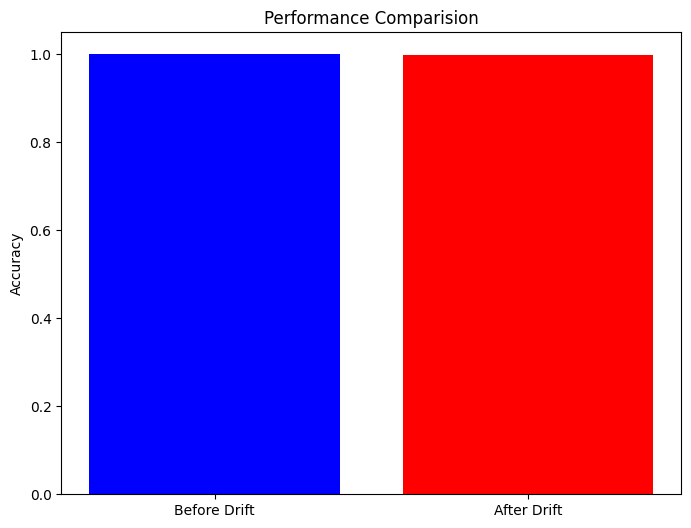

In [ ]:
# Visualization
plt.figure(figsize=(8,6))
plt.bar(
    ['Before Drift', 'After Drift'],
    [acc_before, acc_drift],
    color=['blue', 'red']
    )
plt.ylabel("Accuracy")
plt.title("Performance Comparision")
plt.show()

# Inference
1.  **Original Data (Before Drift):** The initial data `(X1, Y1)` was generated where `Y1` depended on `X1[:,0] + X1[:,1] > 0`. The model was trained and evaluated on this distribution, achieving high accuracy (`acc_before`).

2.  **New Data (After Drift):** The new data `(X2, Y2)` was generated where `Y2` depended on `X2[:,0] - X2[:,1] > 0`. This significantly changes the underlying relationship between the features (`X`) and the target (`Y`).





### Impact on Model Accuracy:
The model was trained on the first data distribution. When it's presented with data from a different distribution (where the relationship between features and target has changed), its performance naturally degrades. Even though the model performs well on `X1`, it struggles with `X2` because the patterns it learned from `X1` are no longer entirely applicable to `X2`.

This is a common challenge in machine learning, especially in real-world applications where data characteristics can evolve over time.